# Mencari Jarak Suara Menggunakan DTW



Sistem ini melakukan pencocokan suara perintah dengan membandingkan rekaman baru dengan 51 sampel suara **“tutup”** menggunakan metode **Dynamic Time Warping (DTW)**. Setiap audio diubah terlebih dahulu menjadi fitur **MFCC**, karena fitur ini mampu mewakili karakteristik akustik dari suara secara lebih stabil dibandingkan bentuk gelombangnya langsung.

Durasi setiap rekaman dapat berbeda-beda, sehingga DTW digunakan untuk menyelaraskan pola waktu antara MFCC suara baru dan MFCC tiap sampel. Proses ini menghasilkan sebuah nilai jarak untuk setiap perbandingan. **Nilai jarak yang lebih kecil menunjukkan kemiripan yang lebih tinggi** antara suara baru dan sampel tersebut.

Setelah seluruh sampel dibandingkan, sistem memilih jarak terkecil sebagai hasil akhir. Jarak terkecil ini menunjukkan sampel suara “tutup” yang paling mirip dengan rekaman baru, sehingga dapat digunakan untuk memutuskan apakah perintah suara yang diberikan termasuk kategori “tutup”.


## Dynamic Time Warping (DTW)

**Dynamic Time Warping (DTW)** adalah sebuah metode untuk menghitung tingkat kemiripan antara dua deret waktu (time series) yang mungkin memiliki panjang berbeda. Pada sistem pengenalan suara, DTW digunakan untuk menyesuaikan pola akustik dari dua sinyal suara meskipun tempo atau durasi ucapannya tidak sama.

DTW bekerja dengan menemukan jalur penyelarasan (warping path) terbaik antara dua urutan fitur, misalnya fitur MFCC dari audio sampel dan audio input baru. Jalur ini dipilih sedemikian rupa sehingga total jarak (cost) antara kedua urutan menjadi minimal.

### Inti Kerja DTW

1. Menghitung jarak lokal antara setiap pasangan elemen fitur dari dua sinyal.
2. Menyusun matriks biaya kumulatif menggunakan dynamic programming.
3. Menemukan jalur optimal melalui matriks yang meminimalkan total biaya.
4. Mengambil nilai akhir sebagai jarak DTW.

Semakin kecil nilai DTW yang dihasilkan, semakin mirip kedua pola suara tersebut.


## Implementasi Pada kasus buka-tutup suara

In [1]:
import librosa
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import soundfile as sf

ModuleNotFoundError: No module named 'librosa'

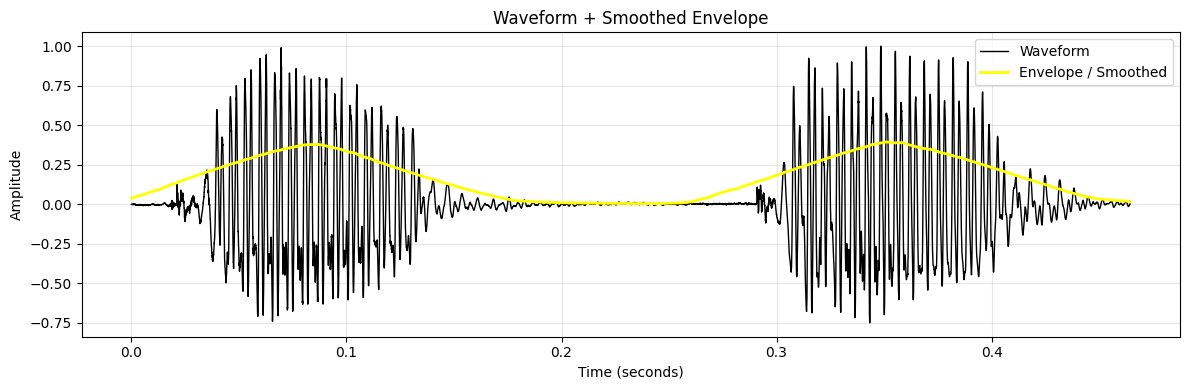

In [ ]:
audio_test = 'data_preprocessed/test/Recording_119.wav'

y, sr = librosa.load(audio_test)

y_trimmed, _ = librosa.effects.trim(y, top_db=20)

y_norm = y_trimmed / np.max(np.abs(y_trimmed))

audio_test_mfcc = librosa.feature.mfcc(y=y_norm, sr=sr, n_mfcc=13)

mfcc_db = librosa.power_to_db(audio_test_mfcc)

times = np.linspace(0, len(y_norm)/sr, num=len(y_norm))

window_size = 2000
envelope = np.convolve(np.abs(y_norm), np.ones(window_size)/window_size, mode='same')

# Plot
plt.figure(figsize=(12, 4))
plt.plot(times, y_norm, color='black', linewidth=1, label='Waveform')     
plt.plot(times, envelope, color='yellow', linewidth=2, label='Envelope / Smoothed')  

plt.title("Waveform + Smoothed Envelope")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



In [48]:
rank = []
path = '../dataset/Ardhi/tutup/'
list_file = os.listdir(path)
for nama_suara in list_file:
    if nama_suara.endswith(".wav"):
        path_audio_train = os.path.join(path, nama_suara)
        y_train, sr_train = librosa.load(path_audio_train)
        mfcc_audio_train = librosa.feature.mfcc(y=y_train, sr=sr_train, n_mfcc=13)
        D, wp = librosa.sequence.dtw(X=audio_test_mfcc, Y=mfcc_audio_train, metric='euclidean')
        distance = D[-1, -1]
        rank.append({
            'filename': nama_suara,
            'jarak': distance,
            'y': y_train,
            'sr': sr_train
        })

rank_urut = sorted(rank, key=lambda item: item['jarak'])

print("Ranking Audio Tutup Paling Mirip")
print("-" * 60)
print(f"| {'No.':<4} | {'Nama File':<25} | {'Jarak':<15} |")
print("-" * 60)

no = 0
for i in rank_urut:
    print(f"| {no+1:<4} | {i['filename']:<25} | {i['jarak']:.10f} |")
    no += 1

print("-" * 60)
        


Ranking Audio Tutup Paling Mirip
------------------------------------------------------------
| No.  | Nama File                 | Jarak           |
------------------------------------------------------------
| 1    | Recording_74.wav          | 8840.8312652890 |
| 2    | Recording_72.wav          | 8938.8620532721 |
| 3    | Recording_83.wav          | 9936.3588296404 |
| 4    | Recording_69.wav          | 10014.6917370220 |
| 5    | Recording_78.wav          | 10095.1294814551 |
| 6    | Recording_70.wav          | 10373.9024838126 |
| 7    | Recording_94.wav          | 10838.5103271981 |
| 8    | Recording_89.wav          | 10991.9427029642 |
| 9    | Recording_86.wav          | 11010.7598362032 |
| 10   | Recording_97.wav          | 11012.3236424470 |
| 11   | Recording_80.wav          | 11139.9174640320 |
| 12   | Recording_66.wav          | 11295.3587537043 |
| 13   | Recording_104.wav         | 11313.5788780929 |
| 14   | Recording_91.wav          | 11434.7260101708 |
| 15   | 

In [49]:
print(f"Paling mirip adalah file {rank_urut[0]['filename']}")

Paling mirip adalah file Recording_74.wav


In [52]:
def grafik(y, sr, title):
    times = np.linspace(0, len(y)/sr, num=len(y))

    # Envelope smoothing
    window_size = 2000
    envelope = np.convolve(np.abs(y), np.ones(window_size)/window_size, mode='same')

    # Plot
    plt.plot(times, y, linewidth=1, label='Waveform', color='black')
    plt.plot(times, envelope, linewidth=2, label='Envelope', color='yellow')
    plt.title(title)
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.grid(True, alpha=0.3)
    plt.legend()

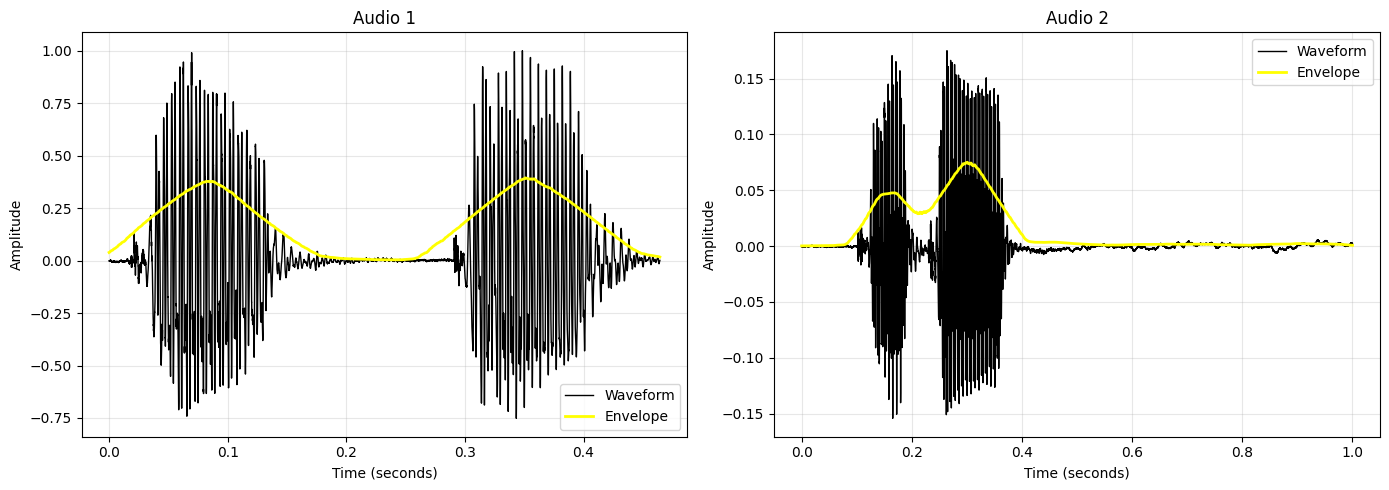

Audio pembanding : 


Audio Paling mirip : 


In [55]:
from IPython.display import Audio, display
# === FIGURE PERBANDINGAN KANAN–KIRI ===
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)  # kiri
grafik(y_norm, sr, "Audio 1")

plt.subplot(1, 2, 2)  # kanan
grafik(rank_urut[0]['y'], rank_urut[0]['sr'], "Audio 2")

plt.tight_layout()
plt.show()

print("Audio pembanding : ")
display(Audio(data=y_norm, rate=sr))
print("Audio Paling mirip : ")
display(Audio(data=rank_urut[0]['y'], rate=rank_urut[0]['sr']))